### Question 3

#### OLS

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.stats.diagnostic as diag

from sklearn.linear_model import LassoCV, Lasso, Ridge, RidgeCV
from sklearn.metrics import r2_score

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [2]:
df = pd.read_csv('FE-GWP1_model_selecxtion_1.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Y       100 non-null    float64
 1   X1      100 non-null    float64
 2   X2      100 non-null    float64
 3   X3      100 non-null    float64
 4   X4      100 non-null    float64
 5   X5      100 non-null    float64
dtypes: float64(6)
memory usage: 4.8 KB


In [4]:
df.head()

,Y,X1,X2,X3,X4,X5
0,3.388410,0.017954,-0.800583,-0.352454,2.187210,1.014887
1,0.287191,0.083057,-0.597947,-0.357639,-1.630284,0.221841
2,3.989645,-0.923437,-1.386575,1.180202,0.632606,-1.576638
3,-2.959602,-0.313775,2.955133,-1.798692,-2.117621,0.159291
4,0.529773,0.388996,1.019611,0.472062,0.590497,0.877048


In [5]:
target = 'Y'
features = df.drop(columns = target).columns.tolist()

In [6]:
# Fit an OLS Regression Model
def train_ols(df, features, target):
    y = df[target]
    X = df[features]
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit()
    
    print(model.summary())

    return model

model = train_ols(df, features, target)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.649
Model:                            OLS   Adj. R-squared:                  0.630
Method:                 Least Squares   F-statistic:                     34.74
Date:                Fri, 13 Jun 2025   Prob (F-statistic):           5.83e-20
Time:                        10:46:11   Log-Likelihood:                -125.30
No. Observations:                 100   AIC:                             262.6
Df Residuals:                      94   BIC:                             278.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1902      0.090     13.246      0.0

**Comment:** 
- Feature X1 is not significant because its p value is 0.881 i.e. greater than 0.05
- The R2 and Asjusted R2 scores look good but there is room for improvement. 

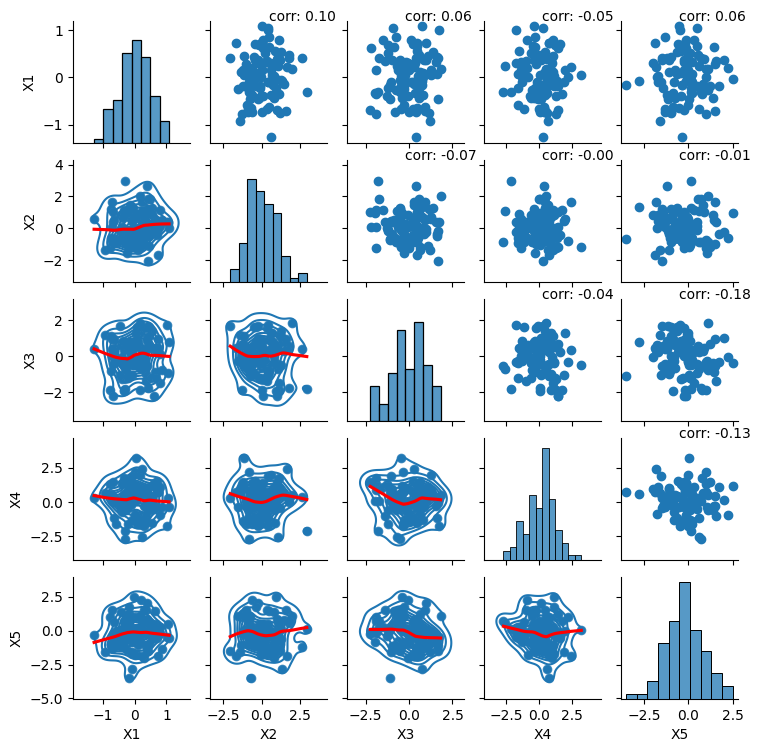

In [7]:
# Check relationship between features
def p_corr(x, y, **kwargs):
    corr_coef = np.corrcoef(x, y)[0][1]

    label = f'corr: {corr_coef:.2f}'
    ax = plt.gca()
    ax.annotate(label, xy = (0.5, 1.0), size = 10, xycoords = ax.transAxes)

grid = sns.pairplot(data = df, vars = features, height = 1.5)
grid.map_upper(p_corr)
grid.map_upper(plt.scatter)

grid = grid.map_lower(sns.kdeplot)
grid = grid.map_lower(sns.regplot, lowess = True, line_kws = {'color': 'red'});

**Comment:**
- From the pairplot, we see that the highest absolute correlation is only 0.18, meaning that there is no linear relationships between the features.
- The red Lowess lines below the diagonal are mostly flat or gently curved; this means that there is also no/weak non-linear patterns between the features.
- So, we can conclude that the variables are mostly independent.

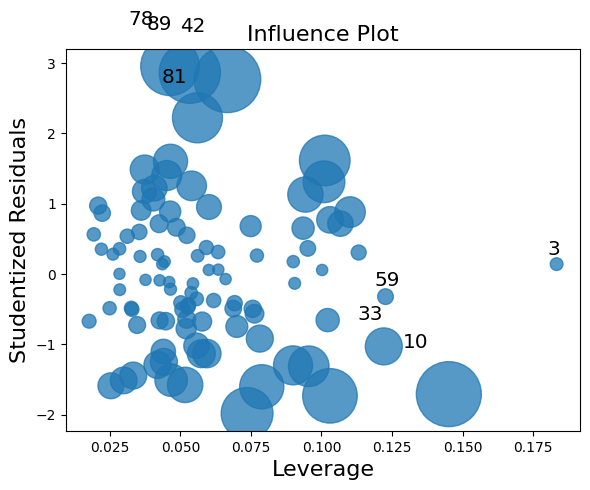

In [8]:
# Check influential points
fig, ax = plt.subplots(figsize = (6, 5))
sm.graphics.influence_plot(model, ax = ax, alpha = 0.05, criterion = "cooks", center = 'cooks')
fig.tight_layout()
plt.show()

In [9]:
influence = model.get_influence()
influence = influence.summary_frame().sort_values('cooks_d', ascending = False)
influence.head()

,dfb_const,dfb_X1,dfb_X2,dfb_X3,dfb_X4,dfb_X5,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
42,0.244746,0.048260,0.180356,0.435382,0.520745,0.189118,0.085196,2.674997,0.066674,0.714964,2.768177,0.739869
10,-0.072347,-0.003105,0.177669,0.323252,-0.005999,0.616926,0.080864,-1.690671,0.145110,-0.696550,-1.707820,-0.703615
89,0.390871,0.169329,-0.357341,-0.114206,-0.053455,0.418742,0.071489,2.758456,0.053363,0.654931,2.862026,0.679521
78,0.247945,0.001181,-0.027747,0.098022,-0.334925,-0.464025,0.065279,2.838636,0.046354,0.625838,2.952896,0.651029
67,-0.170628,-0.187507,0.407324,-0.235821,-0.020235,0.178675,0.056199,-1.713564,0.103008,-0.580685,-1.731686,-0.586826


In [10]:
# Remove these influential points using 4/n threshold
threshold = 4/len(df)
usable_index = influence.query(f'cooks_d < {threshold}').index.tolist()
df = df.iloc[usable_index]
df = df.sort_index(ascending = True)

df.head()

,Y,X1,X2,X3,X4,X5
0,3.388410,0.017954,-0.800583,-0.352454,2.187210,1.014887
1,0.287191,0.083057,-0.597947,-0.357639,-1.630284,0.221841
2,3.989645,-0.923437,-1.386575,1.180202,0.632606,-1.576638
3,-2.959602,-0.313775,2.955133,-1.798692,-2.117621,0.159291
4,0.529773,0.388996,1.019611,0.472062,0.590497,0.877048


In [11]:
# Fit OLS after removing influential points
model = train_ols(df, features, target)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.739
Model:                            OLS   Adj. R-squared:                  0.723
Method:                 Least Squares   F-statistic:                     48.58
Date:                Fri, 13 Jun 2025   Prob (F-statistic):           1.27e-23
Time:                        10:46:22   Log-Likelihood:                -95.341
No. Observations:                  92   AIC:                             202.7
Df Residuals:                      86   BIC:                             217.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1336      0.076     14.971      0.0

**Comment:** 
- Feature X1 remain insignificant with a p value greater than 0.05
- The Adjusted R2 has been improved to 0.723
- AIC and BIC metrics also improved (their values reduced)

This shows that removing influential points had a great impact on our model

In [12]:
# Drop feature X1 to see if the model will improve
new_features = features.copy()
new_features.remove('X1')
model = train_ols(df, new_features, target)

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.738
Model:                            OLS   Adj. R-squared:                  0.726
Method:                 Least Squares   F-statistic:                     61.42
Date:                Fri, 13 Jun 2025   Prob (F-statistic):           1.52e-24
Time:                        10:46:22   Log-Likelihood:                -95.349
No. Observations:                  92   AIC:                             200.7
Df Residuals:                      87   BIC:                             213.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1332      0.075     15.064      0.0

**Comment:**
- The Adjusted R2 slightly improved to 0.726
- The AIC and BIC metrics also reduced a bit

In [13]:
# Check for Heteroskedasticity using Breusch Pagan Test
bp_test = diag.het_breuschpagan(model.resid, model.model.exog)

lm_stat, lm_pvalue, f_stat, f_pvalue = bp_test

print(f"LM p-value: {lm_pvalue}")
print(f"F p-value: {f_pvalue}")

LM p-value: 0.3357284452646724
F p-value: 0.34599972660572714


**Comment:** 
- The p value is greater than 0.05. So, we fail to reject the null hypothesis that says homoskedasticity is present
- The absence of heteroskedasticity imply that there is no need to fit our model using weighted regression models like WLS and Robust Regression because there are no longer extreme points in the dataset

#### Ridge

In [14]:
# For Comparison, let's try Ridge Model
target = 'Y'
features = df.drop(columns = target).columns.tolist()
y = df[target]
X = df[features]

X_scaled = (X - X.min())/(X.max() - X.min())

lambdas = [np.power(10, i) for i in np.arange(4, -4, -0.1)]
ridge_cv = RidgeCV(alphas = lambdas, cv = 10, scoring = 'neg_mean_squared_error').fit(X_scaled, y)

In [15]:
ridge_model = Ridge(alpha = ridge_cv.alpha_, fit_intercept = True).fit(X_scaled, y)
y_pred = ridge_model.predict(X_scaled)

n = len(y)
k = X.shape[1] + 1 

# AIC and BIC
rss = np.sum((y - y_pred) ** 2)
aic = n * np.log(rss / n) + 2 * k
bic = n * np.log(rss / n) + k * np.log(n)

# r2 and Adjusted r2
k -= 1
r2 = r2_score(y, y_pred)
adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))

print(f"AIC: {aic:.3f}")
print(f"BIC: {bic:.3f}")

print(f"R-squared: {r2:.3f}")
print(f"Adjusted R-squared: {adj_r2:.3f}")

AIC: -58.396
BIC: -43.265
R-squared: 0.738
Adjusted R-squared: 0.723


**Conclusion:**
- Both models fit the data similarly (Adjusted R2 of 0.723 and 0.726, respectively).
- Ridge greatly outperforms OLS in AIC and BIC, this means that it is more robust to overfitting.

Even though OLS has slightly better adjusted R2, the much lower AIC/BIC from Ridge makes it the better choice, especially for generalization.